In [3]:
from pathlib import Path
import numpy as np

def load_scanned_object(name):
    if name == "matka_boska":
        e_xy = np.load(Path("data/objects/Matka_Boska/Matka_Boska_data_corr_total_Cu.npz"), allow_pickle=True)["E_xy"]
        peaks = [720, 985, 1594, 2068]
        peak_energies = [3.692, 5.088, 8.046, 10.551]    
    if name == "pigment_palette":
        e_xy = np.load(Path("data/objects/pigment_palette/GEM_Cr_PBS1_PadsPalette_ArCO2_80_20_Gain_35_Thr_35_HV3490_Xray_50kV_1mA_Pinhol_2mm_sum_3-23_GainCorr_Fe.npz"), allow_pickle=True)["E_xy"]
        peaks = [720, 985, 1594, 2068]
        peak_energies = [3.692, 5.088, 8.046, 10.551]    
    else:
        raise ValueError(f"Unknown object name: {name}")

    return e_xy, peaks, peak_energies

def average_patches(e_xy, patch_size):
    A = patch_size
    X, Y, C = e_xy.shape

    X_trim = X - (X % A)
    Y_trim = Y - (Y % A)
    e_xy = e_xy[:X_trim, :Y_trim, :]

    X_prime = X_trim // A
    Y_prime = Y_trim // A
    e_xy_patched = e_xy.reshape(X_prime, A, Y_prime, A, C)
    averaged = e_xy_patched.mean(axis=(1, 3))

    return averaged  # shape will be (X//A, Y//A, C)

In [4]:
object_name = "pigment_palette"
patch_size = 8

e_xy, peaks, peak_energies = load_scanned_object(object_name)
e_xy = average_patches(e_xy, patch_size)
print(e_xy.shape)

(16, 16, 4096)


In [5]:
from src.DataPreprocessor import DataPreprocessor
import numpy as np
from skimage.filters import gaussian

def apply_smoothing_and_padding(e_xy, padding_size=196, spatial_padding=False):
    result = e_xy
    if spatial_padding:
        result = gaussian(result, sigma=0.6)
    result = np.apply_along_axis(
        gaussian, axis=2, arr=result, sigma=16, preserve_range=True
    )
    result[:, :, :padding_size] = 0
    result[:, :, -padding_size:] = 0

    return result 

e_xy_smooth = apply_smoothing_and_padding(e_xy)

/tmp/ipykernel_35937/2538690568.py:5: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(e_xy_smooth[xy], label=xy)


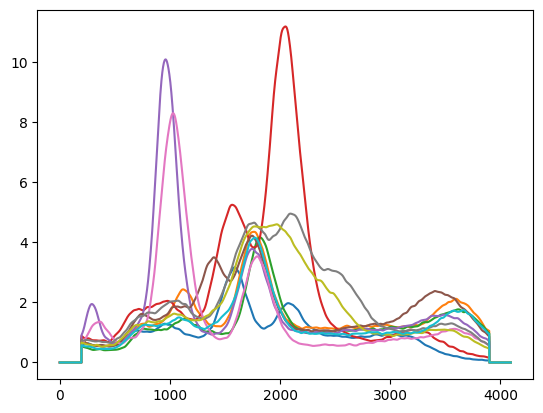

In [8]:
import matplotlib.pyplot as plt
import random 
for i in range(10):
    xy = random.randint(0, e_xy_smooth.shape[0]), random.randint(0, e_xy_smooth.shape[1])
    plt.plot(e_xy_smooth[xy], label=xy)

In [9]:
energy_range, e_xy_processed = DataPreprocessor.processed_spectra(e_xy_smooth, peaks, peak_energies)
H, W, C = e_xy_processed.shape

/home/kyre/repos/masters-thesis/src/DataPreprocessor.py:207: RuntimeWarning: Performing pixel-wise extrapolation, which can be slow for large images.
  warnings.warn("Performing pixel-wise extrapolation, which can be slow for large images.", RuntimeWarning)


In [10]:
import matplotlib.pyplot as plt

def plot_pad_max_peak_positions(e_xy, object_name):
    peak_map = np.argmax(e_xy, axis=2)

    _, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(peak_map, cmap="viridis")
    cbar = plt.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
    cbar.set_label("Max peak position")
    plt.title("Max Peak Positions")
    plt.xlabel("X position")
    plt.ylabel("Y position")
    
    plt.savefig(f"data/plots/max_peak_positions{object_name}.svg", bbox_inches='tight',  pad_inches=0)

def plot_pad_photon_counts(e_xy, object_name): 
    photon_count_map = np.sum(e_xy, axis=2)
    photon_count_map /= np.max(photon_count_map)

    _, ax = plt.subplots(figsize=(8, 8))
    plt.title("Relative Photon Counts")
    plt.xlabel("X position")
    plt.ylabel("Y position")
    im = ax.imshow(photon_count_map, cmap="viridis")
    cbar = plt.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
    cbar.set_label("Relative photon counts")
    
    plt.savefig(f"data/plots/photon_counts{object_name}.svg", bbox_inches='tight',  pad_inches=0)

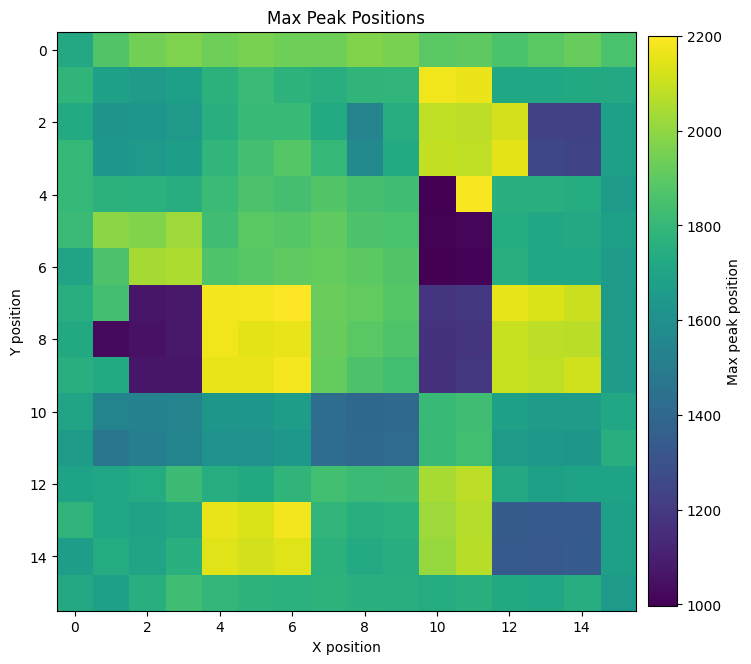

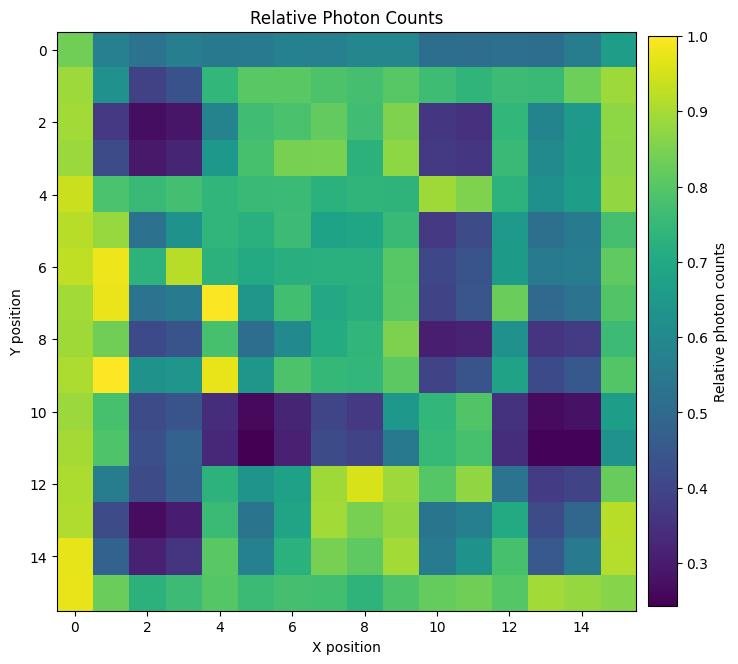

In [11]:
plot_pad_max_peak_positions(e_xy_processed, object_name)
plot_pad_photon_counts(e_xy_processed, object_name)

In [12]:
import numpy as np
import matplotlib.pyplot as plt

wood_spectrum = np.load("data/objects/pigment_palette/1_calibrated_spectra.npz", allow_pickle=True)["wood"]


In [13]:
from src.DataPreprocessor import DataPreprocessor

start = 0.1
stop = 0.5
step = 0.05
e_xy_heuristics = np.zeros_like(e_xy_processed)
best_fractions = np.zeros(e_xy_processed.shape[:-1])

for i in range(e_xy_processed.shape[0]):
    for j in range(e_xy_processed.shape[1]):
        e_xy_heuristics[i, j], best_fractions[i, j]= DataPreprocessor.find_heuristic_subtraction(
            e_xy_processed[i, j], wood_spectrum, start, stop, step
        )
# result = DataPreprocessor.find_heuristic_subtraction(e_xy[5, 5], e_xy[0, 20], start, stop, step)Data

(16, 16)


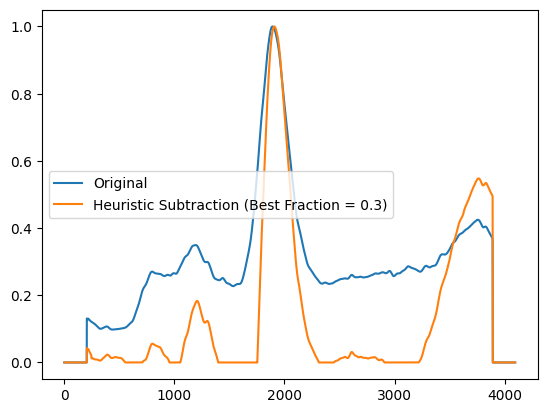

In [14]:
print(best_fractions.shape)
plt.plot(e_xy_processed[5,5], label="Original")
plt.plot(e_xy_heuristics[5,5], label=f"Heuristic Subtraction (Best Fraction = {np.round(best_fractions[i, j], 2)})")
plt.legend()

In [15]:
result = {"e_xy": e_xy_heuristics, "peaks": peaks, "peak_energies": peak_energies, "best_fractions": best_fractions}
np.savez(
    f"data/objects/processed/{object_name}_{patch_size}x{patch_size}_patches.npz", **result
)